## Imports

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [10]:
outline_model = init_chat_model(model = 'groq:llama-3.1-8b-instant')
blog_model = init_chat_model(model = 'groq:openai/gpt-oss-20b')

### Planned flow: **topic -> outline-> blog**  
- First LLM will generate outline from given topic.  
- Second LLM will generate blog from the outline.

## Create State Schema and Node functions

In [12]:
class Blogpost(TypedDict):
    topic: str
    outline: str
    blogpost: str

# function to create outline for blogpost
def create_outline(state: Blogpost) -> Blogpost:
    topic= state['topic']
    outline_prompt = f"Create a thoughful outline for a blogpost on the topic: {topic}. Limit the outline to 2 headers and maximum 3 bullet points per header."
    outline = outline_model.invoke(outline_prompt).content
    state['outline'] = outline
    return state

# function to create blogpost from outline
def create_blogpost(state: Blogpost) -> Blogpost:
    outline = state['outline']
    blogpost_prompt = f"Write a concise blogpost within 300 words based on the following outline: \n{outline}"
    blogpost = blog_model.invoke(blogpost_prompt).content
    state['blogpost'] = blogpost
    return state

## Create graph object

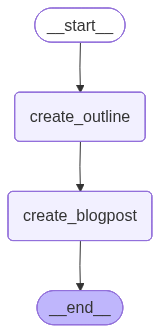

In [13]:
# initialize graph state
graph = StateGraph(Blogpost)

# add nodes to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blogpost', create_blogpost)

# add edges to the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blogpost')
graph.add_edge('create_blogpost', END)

# compile the graph as a workflow
workflow = graph.compile()

## Visualizing the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## Graph Workflow usage

In [14]:
initial_state = {"topic": "Impact of AI in banking sector"}
final_state = workflow.invoke(initial_state)

In [15]:
print(initial_state)
print('--'*40)
print(final_state['outline'])
print('--'*40)
print(final_state['blogpost'])

{'topic': 'Impact of AI in banking sector'}
--------------------------------------------------------------------------------
**I. Benefits of AI in the Banking Sector**

* **Improved Customer Experience**: AI-powered chatbots and virtual assistants can provide 24/7 customer support, helping to resolve queries and complaints efficiently and effectively, thereby enhancing customer satisfaction and loyalty.
* **Enhanced Risk Management**: AI algorithms can analyze vast amounts of data to identify potential risks and detect anomalies, enabling banks to take proactive measures to prevent financial losses and maintain regulatory compliance.
* **Increased Efficiency**: AI can automate routine tasks such as data entry, processing transactions, and detecting errors, freeing up staff to focus on more complex and high-value tasks, leading to increased productivity and reduced costs.

**II. Challenges and Concerns of AI in the Banking Sector**

* **Job Displacement**: The increasing use of AI in b

In [16]:
from IPython.display import Markdown
display(Markdown(final_state['blogpost']))

**AI in Banking: A Double‑Edged Sword**

Artificial intelligence is reshaping the financial industry faster than many regulators can keep pace. While its promise to streamline operations and delight customers is undeniable, the technology also brings fresh risks that banks must manage.

---

### **Benefits**

**1. Improved Customer Experience**  
AI‑powered chatbots and virtual assistants run 24/7, resolving queries, processing transactions, and handling complaints in real time. This constant availability boosts satisfaction, drives loyalty, and frees human agents to tackle more complex issues.

**2. Enhanced Risk Management**  
Machine‑learning models sift through terabytes of data to spot patterns that signal fraud, credit risk, or regulatory violations. By detecting anomalies early, banks can intervene proactively, reducing losses and staying compliant with evolving standards.

**3. Increased Efficiency**  
Robotic process automation handles repetitive tasks—data entry, reconciliation, error detection—at scale and speed. Staff are liberated to focus on strategy and relationship‑building, leading to higher productivity and lower operating costs.

---

### **Challenges**

**1. Job Displacement**  
Automation can render certain roles obsolete, especially those involving routine data handling. The sector faces a pressing need for reskilling programs to transition employees into higher‑value positions, otherwise the workforce could experience significant disruption.

**2. Bias and Security Risks**  
AI systems inherit biases present in training data, potentially leading to discriminatory lending or unfair pricing. Moreover, poorly secured models can become targets for data breaches, exposing sensitive customer information and undermining trust.

**3. Regulatory Compliance**  
Rapid AI adoption strains existing frameworks. Banks must ensure that their systems comply with data protection laws, cybersecurity mandates, and emerging AI‑specific regulations. Failure to do so risks hefty fines and reputational damage.

---

**Bottom line:** AI can deliver unmatched efficiencies and richer customer journeys, but only if banks pair technology deployment with robust governance, transparent models, and a commitment to workforce transformation. The future of banking will belong to those who can balance innovation with responsibility.